In [1]:
%load_ext autoreload
%autoreload 

import torch
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from tqdm import tqdm
import pickle 
from scipy import linalg
import math

from scipy.stats import wasserstein_distance,wasserstein_distance_nd
from itertools import combinations
from src.utils.distance_utils import *

/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [ ]:
# =============================================================
# CONFIGURATION
# =============================================================

# Root directory of this repository
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# Where processed results are stored (download from data repository — see README)
RESULTS_DIR = os.path.join(BASE_DIR, 'processed_results')

# Where to save output figures
FIGS_DIR = os.path.join(BASE_DIR, 'final_figs')
os.makedirs(FIGS_DIR, exist_ok=True)

# Set to False to recompute distances from raw runs
SKIP_COMPUTE = True


In [2]:
plt.rcParams.update({
    "font.size": 14,       # base font size
    "axes.titlesize": 16,  # title
    "axes.labelsize": 15,  # axis labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

In [3]:
variance_explained = 0.7

# MIMIC

## Compute distances

> **Note:** This section recomputes distances from raw model runs stored in `logs/`. This requires the full experiment outputs. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [ ]:
if not SKIP_COMPUTE:
    dataset='mimic'
    label = 'Pleural_Effusion'
    model = 'densenet'
    test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, f'data/MIMIC/{label}/test_labels.csv.gz'))
    test_metadata_df['id'] = test_metadata_df['dicom_id']
    
    model_info_dict = {
        'densenet': {
            'Pleural_Effusion': {
                'lr': 0.000158,
                'balanced_acc_mean': 0.8118672944352877,
                'auc_mean': 0.8978165606821765
            },
        }
    }
    
    results_folder = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
    
    list_of_runs = []
    
    for run in os.listdir(results_folder):
        if os.path.exists(os.path.join(results_folder, run, "features.pt")):
    
            with open(os.path.join(results_folder, run, ".hydra", "config.yaml"), "r") as file:
                config = yaml.safe_load(file)
    
            if config['model']['optimizer']['lr'] == model_info_dict[model][label]['lr']:
                list_of_runs.append(os.path.join(results_folder,run))

In [5]:
if not SKIP_COMPUTE:
    # --- collect explained-variance ratios per seed while you already loop runs ---
    var_ratio_by_seed = {}   # seed -> np.array of length >= n_components
    
    explained_components_list = []
    n_components = 20*2
    
    for run_folder in list_of_runs:
        with open(os.path.join(run_folder, '.hydra', 'config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
            features = torch.load(os.path.join(run_folder, 'features.pt'))
    
            test_preds = pd.read_csv(os.path.join(run_folder, 'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            var_ratio_by_seed[seed], n_components_70 = determine_pca_components(features, preds_metadata_df, variance_explained)
    
            explained_components_list.append(n_components_70)
    
    avg_components = np.mean(explained_components_list)
    print(f"Average number of components to explain ≥{variance_explained*100}% variance: {avg_components:.2f}")

Average number of components to explain ≥70.0% variance: 3.00


In [6]:
if not SKIP_COMPUTE:
    experiment_dict = {}
    
    for run in list_of_runs:
    
        with open(os.path.join(run,'.hydra','config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
    
            features = torch.load(os.path.join(run,'features.pt'))
            test_preds = pd.read_csv(os.path.join(run,'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            results_df, sum_explained_variance = conduct_pca(features,preds_metadata_df,n_pc=n_components) # calculate on more components so you can reuse later
    
            experiment_dict[seed] = results_df

In [ ]:
if not SKIP_COMPUTE:
    attributes = [
        "ViewPosition_binary", "PatientOrientationCodeSequence_CodeMeaning_binary",
        "PerformedProcedureStepDescription_binary", "Support_Devices_binary",
        "Gender_binary", "Insurance_binary", "Language_binary",
        "Marital_Status_binary", "Race_cat_binary", "Age_binary", "Random_binary"
    ]
    
    wd_df = calc_wd_df(experiment_dict,attributes,avg_components)
    fd_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='FD', distance_function = compute_frechet_distance, dimension_reduction=False,avg_components=avg_components)
    tvd_hist_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='TVD', distance_function = compute_tvd, dimension_reduction=False,avg_components=avg_components)

In [ ]:
if not SKIP_COMPUTE:
    df_all_metrics = wd_df.join(fd_df)
    df_all_metrics = df_all_metrics.join(tvd_hist_df)
    
    df_all_metrics.to_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/{label.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))

## Visualise distances

In [11]:
df_all_metrics = pd.read_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/{label.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
df_all_metrics.set_index('Unnamed: 0',inplace=True)
rename_map = {
    "ViewPosition": "ViewPosition",
    "PatientOrientationCodeSequence_CodeMeaning": "PatientOrientation",
    "PerformedProcedureStepDescription": "Procedure",
    "Support_Devices": "Support_Devices",
    "Gender": "Gender",
    "Insurance": "Insurance",
    "Language": "Language",
    "Marital_Status": "Marital_Status",
    "Race_cat": "Race_cat",
    "Age": "Age",
    "Random": "Random"
}

df_all_metrics = df_all_metrics.rename(index=rename_map)

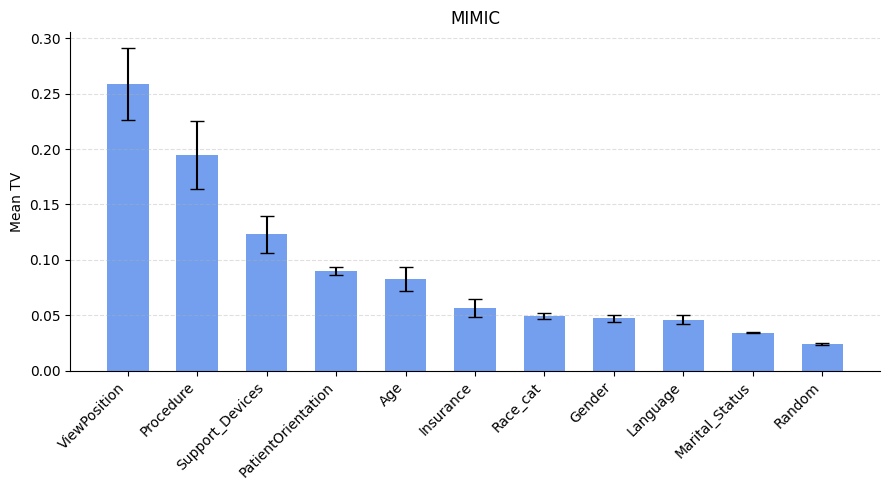

In [15]:
metric = 'TVD'
col_mean = f"{metric}_g0_vs_g1_mean"

df_plot = df_all_metrics.sort_values(by=col_mean, ascending=False)

x = np.arange(len(df_plot.index))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x, df_plot[col_mean],
    0.6,
    yerr=df_plot[f"{metric}_g0_vs_g1_std"],
    capsize=5, alpha=0.9,
    color='cornflowerblue',
    ecolor="black"
)

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=45, ha="right")
ax.set_ylabel("Mean TV")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title('MIMIC')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'MIMIC_tv.pdf'))
plt.show()

# MNIST

## Compute distances

> **Note:** This section recomputes distances from raw model runs stored in `logs/`. This requires the full experiment outputs. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [31]:
if not SKIP_COMPUTE:
    dataset='mnist'
    label ='parity'
    test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, f'data/MNIST/{label}/test_labels.csv'))
    test_metadata_df['id'] = test_metadata_df['image_index']
    
    results_folder = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
    
    list_of_runs = []
    
    for run in os.listdir(results_folder):
        if os.path.exists(os.path.join(results_folder, run, "features.pt")):
    
            with open(os.path.join(results_folder, run, ".hydra", "config.yaml"), "r") as file:
                config = yaml.safe_load(file)
    
            if config['model']['optimizer']['lr'] == model_info_dict[label]['lr']:
                list_of_runs.append(os.path.join(results_folder,run))

FileNotFoundError: [Errno 2] No such file or directory: 'logs/alloc_baseline_pretrain/runs'

In [ ]:
if not SKIP_COMPUTE:
    # --- collect explained-variance ratios per seed while you already loop runs ---
    var_ratio_by_seed = {}   # seed -> np.array of length >= n_components
    
    explained_components_list = []
    n_components = 108
    
    for run_folder in list_of_runs:
        with open(os.path.join(run_folder, '.hydra', 'config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
            features = torch.load(os.path.join(run_folder, 'features.pt'))
    
            test_preds = pd.read_csv(os.path.join(run_folder, 'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            var_ratio_by_seed[seed], n_components_70 = determine_pca_components(features, preds_metadata_df, 0.7)
    
            explained_components_list.append(n_components_70)
    
    avg_components = np.mean(explained_components_list)
    print(f"Average number of components to explain ≥70% variance: {avg_components:.2f}")

In [ ]:
if not SKIP_COMPUTE:
    experiment_dict = {}
    
    for run in list_of_runs:
    
        with open(os.path.join(run,'.hydra','config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
    
            features = torch.load(os.path.join(run,'features.pt'))
            test_preds = pd.read_csv(os.path.join(run,'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            results_df, sum_explained_variance = conduct_pca(features,preds_metadata_df,n_pc=n_components) # calculate on more components so you can reuse later
    
            experiment_dict[seed] = results_df

In [ ]:
if not SKIP_COMPUTE:
    attributes = ["S","A", "Random_binary"]
    
    wd_df = calc_wd_df(experiment_dict,attributes,avg_components)
    fd_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='FD', distance_function = compute_frechet_distance, dimension_reduction=False,avg_components=avg_components)
    tvd_hist_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='TVD', distance_function = compute_tvd, dimension_reduction=False,avg_components=avg_components)

In [ ]:
if not SKIP_COMPUTE:
    df_all_metrics = wd_df.join(fd_df)
    df_all_metrics = df_all_metrics.join(tvd_hist_df)
    
    df_all_metrics.to_csv(os.path.join(RESULTS_DIR, f'{dataset}/{label.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))

In [32]:
df_all_metrics = pd.read_csv(os.path.join(RESULTS_DIR, f'{dataset}/pretrain_mean_distances_correct_pcs_stds.csv'))
df_all_metrics.set_index('Unnamed: 0',inplace=True)


## Visualise distances

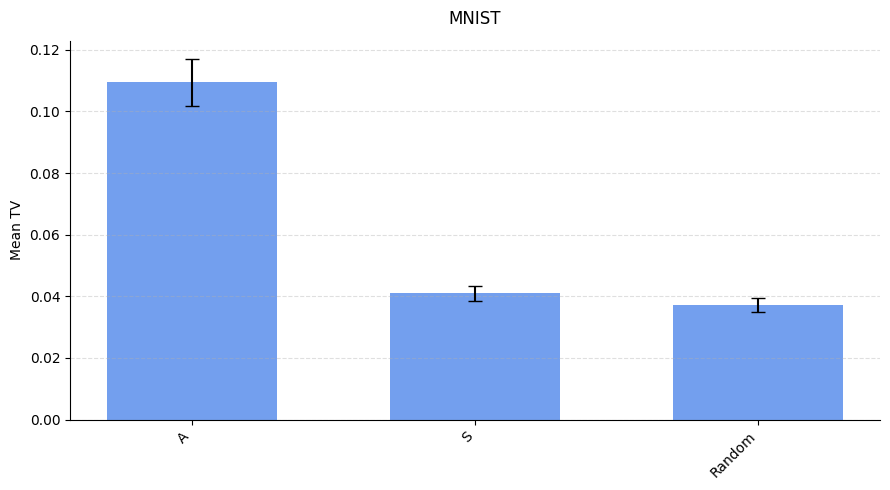

In [33]:
metric = 'TVD'
x = np.arange(len(df_all_metrics.index))  # positions for attributes
width = 0.6  # slightly thinner looks cleaner
df_all_metrics.sort_values(by='TVD_g0_vs_g1_mean', ascending=False,inplace=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x, df_all_metrics[f"{metric}_g0_vs_g1_mean"],
    width,
    yerr=df_all_metrics[f"{metric}_g0_vs_g1_std"],
    capsize=5, alpha=0.9,
    color='cornflowerblue',
    ecolor="black"
)
ax.set_xticks(x)
ax.set_xticklabels(df_all_metrics.index, rotation=45, ha="right")
ax.set_ylabel("Mean TV")
ax.set_title("MNIST", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'mnist_TV.pdf'))
plt.show()

# HAM10000

## Compute distances

> **Note:** This section recomputes distances from raw model runs stored in `logs/`. This requires the full experiment outputs. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [ ]:
if not SKIP_COMPUTE:
    PRETRAINED=True
    
    dataset='ham'
    label='lesion'
    model = 'ViT'
    model_info_dict = {
        'ViT': {
            'lesion': {
                'lr': 0.000065, #0.000065
                'balanced_acc_mean': 0.7779948726340479,
                'auc_mean': 0.8894147166312115
            }
        }
    }
    test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/HAM10000/test_labels.csv'))
    test_metadata_df['id'] = test_metadata_df['image_id']
    
    results_folder = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
    
    list_of_runs = []
    
    for run in os.listdir(results_folder):
        if os.path.exists(os.path.join(results_folder, run, "features.pt")):
    
            with open(os.path.join(results_folder, run, ".hydra", "config.yaml"), "r") as file:
                config = yaml.safe_load(file)
    
            if config['model']['optimizer']['lr'] == model_info_dict[model][label]['lr']:
                list_of_runs.append(os.path.join(results_folder,run))

In [5]:
if not SKIP_COMPUTE:
    # --- collect explained-variance ratios per seed while you already loop runs ---
    var_ratio_by_seed = {}   # seed -> np.array of length >= n_components
    
    explained_components_list = []
    n_components = 700
    
    for run_folder in list_of_runs:
        with open(os.path.join(run_folder, '.hydra', 'config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
            features = torch.load(os.path.join(run_folder, 'features.pt'))
    
            test_preds = pd.read_csv(os.path.join(run_folder, 'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            var_ratio_by_seed[seed], n_components_70 = determine_pca_components(features, preds_metadata_df, variance_explained)
    
            explained_components_list.append(n_components_70)
    
    avg_components = np.mean(explained_components_list)
    print(f"Average number of components to explain ≥70% variance: {avg_components:.2f}")

Average number of components to explain ≥70% variance: 47.00


In [6]:
if not SKIP_COMPUTE:
    experiment_dict = {}
    
    for run in list_of_runs:
    
        with open(os.path.join(run,'.hydra','config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
    
            features = torch.load(os.path.join(run,'features.pt'))
            test_preds = pd.read_csv(os.path.join(run,'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            results_df, sum_explained_variance = conduct_pca(features,preds_metadata_df,n_pc=n_components) # calculate on more components so you can reuse later
    
            experiment_dict[seed] = results_df

In [ ]:
if not SKIP_COMPUTE:
    attributes = ['Sex_binary', 'Age_binary','Dataset_binary', 'Localization_binary','Random_binary']
    
    wd_df = calc_wd_df(experiment_dict,attributes,avg_components)
    fd_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='FD', distance_function = compute_frechet_distance, dimension_reduction=False,avg_components=avg_components)
    tvd_hist_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='TVD', distance_function = compute_tvd, dimension_reduction=False,avg_components=avg_components)

In [ ]:
if not SKIP_COMPUTE:
    df_all_metrics = wd_df.join(fd_df)
    df_all_metrics = df_all_metrics.join(tvd_hist_df)
    
    df_all_metrics.to_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))

In [ ]:
df_all_metrics = pd.read_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
df_all_metrics.set_index('Unnamed: 0',inplace=True)


## Visualise distances

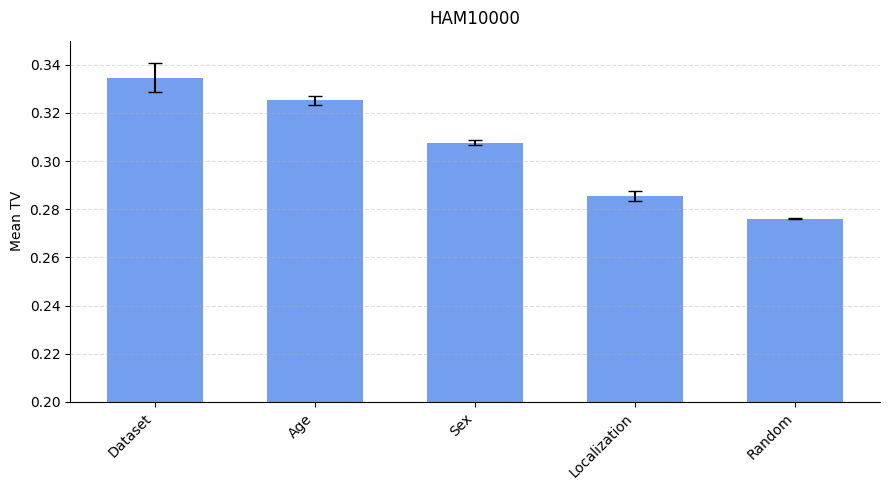

In [28]:
metric = 'TVD'
x = np.arange(len(df_all_metrics.index))  # positions for attributes
width = 0.6  # slightly thinner looks cleaner
df_all_metrics.sort_values(by='TVD_g0_vs_g1_mean', ascending=False,inplace=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x, df_all_metrics[f"{metric}_g0_vs_g1_mean"],
    width,
    yerr=df_all_metrics[f"{metric}_g0_vs_g1_std"],
    capsize=5, alpha=0.9,
    color='cornflowerblue',
    ecolor="black"
)
ax.set_xticks(x)
ax.set_xticklabels(df_all_metrics.index, rotation=45, ha="right")
ax.set_ylabel("Mean TV")
ax.set_title("HAM10000", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.ylim([0.2,0.35])
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'ham_TV.pdf'))
plt.show()

# CIVIL COMMENTS

## Compute distances

> **Note:** This section recomputes distances from raw model runs stored in `logs/`. This requires the full experiment outputs. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [ ]:
if not SKIP_COMPUTE:
    dataset='civilcomments'
    label='toxicity'
    model = 'bert'
    model_info_dict = {
        'bert': {
            'toxicity': {
                'lr': 0.000222,
                'balanced_acc_mean': 0.7779948726340479,
                'auc_mean': 0.8894147166312115
            }
        }
    }
    test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/CIVILCOMMENTS/test_labels.csv'))
    
    results_folder = os.path.join(BASE_DIR, 'logs/alloc_baseline_pretrain/runs')
    
    list_of_runs = []
    
    for run in os.listdir(results_folder):
        if os.path.exists(os.path.join(results_folder, run, "features.pt")):
    
            with open(os.path.join(results_folder, run, ".hydra", "config.yaml"), "r") as file:
                config = yaml.safe_load(file)
    
            if config['model']['optimizer']['lr'] == model_info_dict[model][label]['lr']:
                list_of_runs.append(os.path.join(results_folder,run))

In [34]:
if not SKIP_COMPUTE:
    # --- collect explained-variance ratios per seed while you already loop runs ---
    var_ratio_by_seed = {}   # seed -> np.array of length >= n_components
    
    explained_components_list = []
    n_components = 20*2
    
    for run_folder in list_of_runs:
        with open(os.path.join(run_folder, '.hydra', 'config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
            features = torch.load(os.path.join(run_folder, 'features.pt'))
    
            test_preds = pd.read_csv(os.path.join(run_folder, 'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            var_ratio_by_seed[seed], n_components_70 = determine_pca_components(features, preds_metadata_df, variance_explained)
    
            explained_components_list.append(n_components_70)
    
    avg_components = np.mean(explained_components_list)
    print(f"Average number of components to explain ≥70% variance: {avg_components:.2f}")

Average number of components to explain ≥70% variance: nan


/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [12]:
if not SKIP_COMPUTE:
    experiment_dict = {}
    
    for run in list_of_runs:
    
        with open(os.path.join(run,'.hydra','config.yaml'), "r") as file:
            config = yaml.safe_load(file)
            seed = config['seed']
    
            features = torch.load(os.path.join(run,'features.pt'))
            test_preds = pd.read_csv(os.path.join(run,'preds.csv'))
            preds_metadata_df = pd.merge(test_preds, test_metadata_df, on='id', how='left')
    
            results_df, sum_explained_variance = conduct_pca(features,preds_metadata_df,n_pc=n_components) # calculate on more components so you can reuse later
    
            experiment_dict[seed] = results_df

In [ ]:
if not SKIP_COMPUTE:
    attributes = ['Gender_binary','Orientation_binary','Religion_binary','Race_binary', 'Year_binary', 'Random_binary']
    
    wd_df = calc_wd_df(experiment_dict,attributes,avg_components)
    fd_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='FD', distance_function = compute_frechet_distance, dimension_reduction=False,avg_components=avg_components)
    tvd_hist_df = calc_distance_df(list_of_runs, experiment_dict, test_metadata_df, attributes, distance_metric='TVD', distance_function = compute_tvd, dimension_reduction=False,avg_components=avg_components)

In [ ]:
if not SKIP_COMPUTE:
    df_all_metrics = wd_df.join(fd_df)
    df_all_metrics = df_all_metrics.join(tvd_hist_df)
    
    df_all_metrics.to_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))

In [37]:
df_all_metrics = pd.read_csv(os.path.join(RESULTS_DIR, f'{dataset}/{model.lower()}/pretrain_mean_distances_correct_pcs_stds.csv'))
df_all_metrics.set_index('Unnamed: 0',inplace=True)
df_all_metrics.sort_values(by='TVD_g0_vs_g1_mean', ascending=False,inplace=True)

## Visualise distances

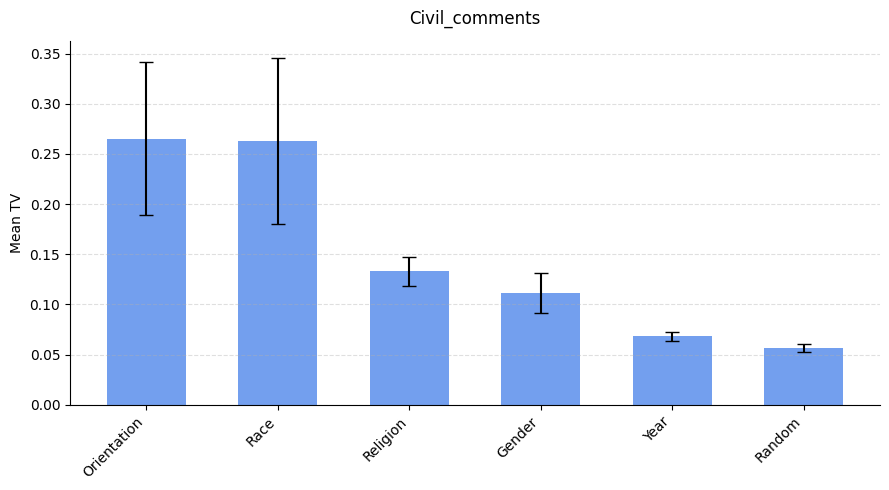

In [39]:
metric = 'TVD'
x = np.arange(len(df_all_metrics.index))  # positions for attributes
width = 0.6  # slightly thinner looks cleaner

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x, df_all_metrics[f"{metric}_g0_vs_g1_mean"],
    width,
    yerr=df_all_metrics[f"{metric}_g0_vs_g1_std"],
    capsize=5, alpha=0.9,
    color='cornflowerblue',
    ecolor="black"
)
ax.set_xticks(x)
ax.set_xticklabels(df_all_metrics.index, rotation=45, ha="right")
ax.set_ylabel("Mean TV")
ax.set_title("Civil_comments", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'civilcomments_TV.pdf'))
plt.show()